In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport


In [85]:
df = pd.read_csv("/home/tanmoy/Desktop/Phitron/Machine Learning/Module3 Train Split/Practice/titanic_data_updated.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [86]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [87]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [88]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
450,no,second,male,36.00,1,2,27.7500,NaN,S
284,no,first,male,NaN,0,0,26.0000,A19,S
594,no,second,male,37.00,1,0,26.0000,NaN,S
200,no,third,male,28.00,0,0,9.5000,NaN,S
469,yes,third,female,0.75,2,1,19.2583,NaN,C


In [89]:
print(df['Age'].isnull().sum())

177


## Feature and taget column ke alada kora 

In [90]:
x = df.drop(columns=['Survived'])
x.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S


In [91]:
y = df['Survived']
y.head(5)

0     no
1    yes
2    yes
3    yes
4     no
Name: Survived, dtype: object

## Train Test Split

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)

In [94]:
train_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [95]:
test_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


## Filling missing using pandas

In [96]:
mn = train_x['Age'].mean()
mn

np.float64(29.498846153846156)

In [97]:
train_x['mean'] = train_x['Age'].fillna(mn)
train_x



,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,mean
331,first,male,45.5,0,0,28.5000,C124,S,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000


In [98]:
train_x['mean'].isnull().sum()

np.int64(0)

In [99]:
md = df['Age'].median()
md

28.0

In [100]:
train_x['mode'] = train_x['Age'].fillna(md)
train_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,mean,mode
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


In [101]:
train_x['mode'].isnull().sum()

np.int64(0)

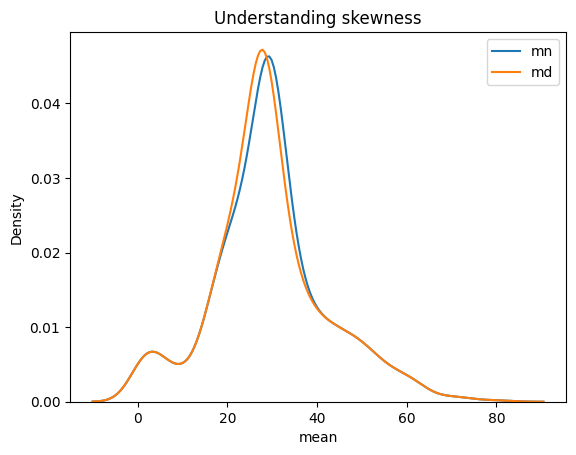

In [102]:
plt.title("Understanding skewness")
sns.kdeplot(data=train_x, x = 'mean', label='mn')
sns.kdeplot(data=train_x, x = 'mode', label='md')
plt.legend()
plt.show()

## Sklearn diye dekhbo ekhon 

In [103]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(train_x[['Age']])
train_x['Age'] = age_imputer.transform(train_x[['Age']])

In [104]:
train_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
mean          0
mode          0
dtype: int64

In [105]:
age_imputer.fit(test_x[['Age']])
test_x['Age'] = age_imputer.transform(test_x[['Age']])

In [106]:
test_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [107]:
from sklearn.impute import SimpleImputer

e = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

e.fit(train_x[['Embarked']])

train_x['Embarked'] = e.transform(train_x[['Embarked']]).ravel()
test_x['Embarked'] = e.transform(test_x[['Embarked']]).ravel()

In [108]:
train_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
mean          0
mode          0
dtype: int64

In [109]:
test_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [111]:
cabin_update = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)

cabin_update.fit(train_x[['Cabin']])

train_x[['Cabin', 'cabin_missing_indicator']] = cabin_update.transform(train_x[['Cabin']])
test_x[['Cabin', 'cabin_missing_indicator']] = cabin_update.transform(test_x[['Cabin']])

In [112]:
train_x.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
mean                       0
mode                       0
cabin_missing_indicator    0
dtype: int64

In [113]:
test_x.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64